#### Nguyễn Thành Lộc   
#### 2351060016

# Sáng Thực Hành

## 1.Introduce to NN

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import os



In [3]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
# Create output directory if it doesn't exist
output_dir = "02_neural_networks_fundamentals_outputs"
os.makedirs(output_dir, exist_ok=True)

Using device: cpu
PyTorch version: 2.11.0+cpu


## 2.Perceptron The Perceptron: The Simplest Neural Network

output = activation(sum(weights_i * input_i) + bias)

In [4]:
# Create a perceptron with 2 inputs and 1 output
perceptron_layer = nn.Linear(2, 1).to(device)
sample_input = torch.tensor([0.5, -1.0], device=device)
# Forward pass through perceptron
weighted_sum = perceptron_layer(sample_input)
output = torch.sigmoid(weighted_sum) # Using sigmoid as activation
print(f"Sample input: {sample_input.cpu().numpy()}")
print(f"Perceptron weights: {perceptron_layer.weight.data.cpu().numpy()}")
print(f"Perceptron bias: {perceptron_layer.bias.data.cpu().numpy()}")
print(f"Weighted sum + bias: {weighted_sum.item():.4f}")
print(f"Output after sigmoid: {output.item():.4f}")
print("\nNote: Single-layer perceptron can only solve linearly separable ")

Sample input: [ 0.5 -1. ]
Perceptron weights: [[0.5406104 0.5869042]]
Perceptron bias: [-0.16565567]
Weighted sum + bias: -0.4823
Output after sigmoid: 0.3817

Note: Single-layer perceptron can only solve linearly separable 


## 3.Activation Functions



#### Giup mo hinh hoc duoc tinh phi tuyen cua ham minh chua biet

In [5]:
# Create input values for plotting activation functions
x_vals = torch.linspace(-6, 6, 100)
# Define activation functions
sigmoid_fn = nn.Sigmoid()
tanh_fn = nn.Tanh()
relu_fn = nn.ReLU()
leaky_relu_fn = nn.LeakyReLU(negative_slope=0.1)
# Compute outputs
y_sigmoid = sigmoid_fn(x_vals)
y_tanh = tanh_fn(x_vals)
y_relu = relu_fn(x_vals)
y_leaky_relu = leaky_relu_fn(x_vals)
print("Activation Functions Computed:")
print(f"Sigmoid range: [{y_sigmoid.min():.3f}, {y_sigmoid.max():.3f}]")
print(f"Tanh range: [{y_tanh.min():.3f}, {y_tanh.max():.3f}]")
print(f"ReLU range: [{y_relu.min():.3f}, {y_relu.max():.3f}]")
print(f"Leaky ReLU range: [{y_leaky_relu.min():.3f}, {y_leaky_relu.max():.3f}]")

Activation Functions Computed:
Sigmoid range: [0.002, 0.998]
Tanh range: [-1.000, 1.000]
ReLU range: [0.000, 6.000]
Leaky ReLU range: [-0.600, 6.000]


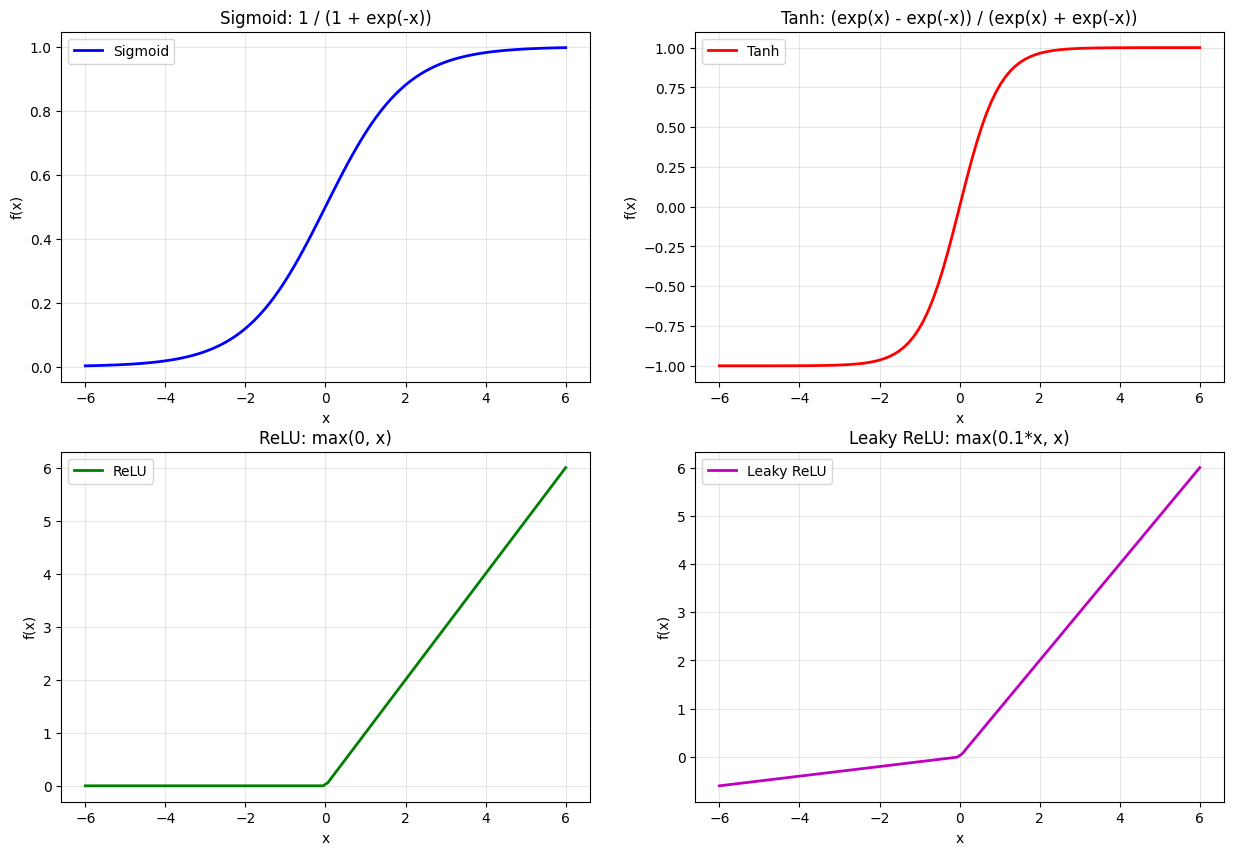

In [6]:
# Plot activation functions
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.plot(x_vals.numpy(), y_sigmoid.numpy(), 'b-', linewidth=2, label='Sigmoid')
plt.title('Sigmoid: 1 / (1 + exp(-x))')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(x_vals.numpy(), y_tanh.numpy(), 'r-', linewidth=2, label='Tanh')
plt.title('Tanh: (exp(x) - exp(-x)) / (exp(x) + exp(-x))')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(x_vals.numpy(), y_relu.numpy(), 'g-', linewidth=2, label='ReLU')
plt.title('ReLU: max(0, x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(x_vals.numpy(), y_leaky_relu.numpy(), 'm-', linewidth=2, label='Leaky ReLU')
plt.title('Leaky ReLU: max(0.1*x, x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
#plt.tight_layout()
plt.show()


In [7]:
# Demonstrate Softmax activation
softmax_fn = nn.Softmax(dim=1)
sample_logits = torch.tensor([[1.0, -0.5, 2.0], [0.1, 0.5, 0.2]]) # Batc
y_softmax = softmax_fn(sample_logits)
print("Softmax Activation Function:")
print("-" * 30)
print("Sample Logits:")
print(sample_logits)
print("\nSoftmax Output (probabilities that sum to 1):")
print(y_softmax)
print(f"\nSum of probabilities for sample 1: {y_softmax[0].sum():.4f}")
print(f"Sum of probabilities for sample 2: {y_softmax[1].sum():.4f}")


Softmax Activation Function:
------------------------------
Sample Logits:
tensor([[ 1.0000, -0.5000,  2.0000],
        [ 0.1000,  0.5000,  0.2000]])

Softmax Output (probabilities that sum to 1):
tensor([[0.2537, 0.0566, 0.6897],
        [0.2780, 0.4147, 0.3072]])

Sum of probabilities for sample 1: 1.0000
Sum of probabilities for sample 2: 1.0000


## 4.Multi-layer


In [8]:
# Define a Multi-Layer Perceptron
class SimpleMLP(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(SimpleMLP, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size) # Input t
    self.relu1 = nn.ReLU() # First a
    self.fc2 = nn.Linear(hidden_size, hidden_size // 2) # Hidden
    self.relu2 = nn.ReLU() # Second
    self.fc3 = nn.Linear(hidden_size // 2, num_classes) # Final l
  def forward(self, x):
    print(f" Input shape: {x.shape}")
    out = self.fc1(x)
    print(f" After fc1: {out.shape}")
    out = self.relu1(out)
    print(f" After relu1: {out.shape}")
    out = self.fc2(out)
    print(f" After fc2: {out.shape}")
    out = self.relu2(out)
    print(f" After relu2: {out.shape}")
    out = self.fc3(out)
    print(f" Output shape (logits): {out.shape}")
    return out


In [9]:
# Create and examine the MLP
input_dim = 100
hidden_dim = 64
output_dim = 5
model = SimpleMLP(input_dim, hidden_dim, output_dim).to(device)
print("MLP Architecture:")
print(model)


MLP Architecture:
SimpleMLP(
  (fc1): Linear(in_features=100, out_features=64, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=32, out_features=5, bias=True)
)


In [10]:
x=torch.rand(1,100)
print(x)

tensor([[0.4448, 0.6687, 0.1666, 0.4539, 0.3316, 0.3814, 0.3186, 0.8200, 0.2543,
         0.1626, 0.7160, 0.6620, 0.5052, 0.5412, 0.9908, 0.3327, 0.0538, 0.0075,
         0.6296, 0.6949, 0.5071, 0.0845, 0.1094, 0.1593, 0.8219, 0.5980, 0.2215,
         0.0271, 0.7873, 0.5054, 0.9970, 0.0903, 0.0945, 0.5863, 0.8351, 0.8303,
         0.9971, 0.8183, 0.7233, 0.1926, 0.9927, 0.2787, 0.8215, 0.7057, 0.2036,
         0.4553, 0.4584, 0.8775, 0.8826, 0.6072, 0.2159, 0.6424, 0.9097, 0.2350,
         0.9007, 0.6130, 0.7766, 0.6715, 0.8157, 0.0746, 0.7065, 0.0664, 0.4659,
         0.8910, 0.0900, 0.1197, 0.2809, 0.5188, 0.4309, 0.1075, 0.5651, 0.3744,
         0.2665, 0.5055, 0.6698, 0.5802, 0.1685, 0.8389, 0.5943, 0.2953, 0.9328,
         0.6008, 0.7600, 0.8535, 0.4911, 0.9121, 0.4978, 0.9000, 0.5606, 0.7301,
         0.7518, 0.2229, 0.9369, 0.5152, 0.6838, 0.1311, 0.3134, 0.8259, 0.1844,
         0.5693]])


In [11]:
model.forward(x.to(device))

 Input shape: torch.Size([1, 100])
 After fc1: torch.Size([1, 64])
 After relu1: torch.Size([1, 64])
 After fc2: torch.Size([1, 32])
 After relu2: torch.Size([1, 32])
 Output shape (logits): torch.Size([1, 5])


tensor([[ 0.1714,  0.0410, -0.2010,  0.0659, -0.0837]],
       grad_fn=<AddmmBackward0>)

In [12]:
np.sum([ 0.1896,  0.0296, -0.1891,  0.0453, -0.0994])

np.float64(-0.02399999999999998)

In [13]:
# Count parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")
# Demonstrate forward propagation
print("\nDemonstrating Forward Propagation:")
print("-" * 40)
batch_size = 4
dummy_input = torch.randn(batch_size, input_dim).to(device)
print(f"Input batch shape: {dummy_input.shape}")
with torch.no_grad():
 predictions = model(dummy_input)
print(f"\nOutput predictions shape: {predictions.shape}")
print("Output for first sample (raw logits):")
print(predictions[0].cpu().numpy())


Total trainable parameters: 8,709

Demonstrating Forward Propagation:
----------------------------------------
Input batch shape: torch.Size([4, 100])
 Input shape: torch.Size([4, 100])
 After fc1: torch.Size([4, 64])
 After relu1: torch.Size([4, 64])
 After fc2: torch.Size([4, 32])
 After relu2: torch.Size([4, 32])
 Output shape (logits): torch.Size([4, 5])

Output predictions shape: torch.Size([4, 5])
Output for first sample (raw logits):
[ 0.14501026  0.13493873 -0.0829394   0.00831889 -0.14175405]


## 5.nnModule

In [14]:
print("PyTorch nn.Module Key Points:")
print("=" * 40)
print("✓ Networks inherit from nn.Module")
print("✓ Layers defined as attributes in __init__")
print("✓ forward() method defines data flow")
print("✓ Automatic parameter tracking")
print("✓ Built-in layers: nn.Linear, nn.Conv2d, etc.")
print("=" * 40)
# Examine the SimpleMLP class structure
print("\nSimpleMLP Class Structure:")
print("- __init__: Defines layers (fc1, relu1, fc2, relu2, fc3)")
print("- forward: Defines computation flow")
print("- Inherits from nn.Module for automatic parameter management")

PyTorch nn.Module Key Points:
✓ Networks inherit from nn.Module
✓ Layers defined as attributes in __init__
✓ forward() method defines data flow
✓ Automatic parameter tracking
✓ Built-in layers: nn.Linear, nn.Conv2d, etc.

SimpleMLP Class Structure:
- __init__: Defines layers (fc1, relu1, fc2, relu2, fc3)
- forward: Defines computation flow
- Inherits from nn.Module for automatic parameter management


 ## 6.Loss Functions: do sai so mo hinh

In [15]:
# Demonstrate different loss functions
print("Loss Functions Demonstration:")
print("=" * 40)

# Mean Squared Error (MSE) - For Regression
loss_mse_fn = nn.MSELoss()
predictions_reg = torch.tensor([1.0, 2.5, 3.8], device=device)
targets_reg = torch.tensor([1.2, 2.3, 4.0], device=device)
mse = loss_mse_fn(predictions_reg, targets_reg)
print("1. MSE Loss (Regression):")
print(f" Predictions: {predictions_reg.cpu().numpy()}")
print(f" Targets: {targets_reg.cpu().numpy()}")
print(f" MSE Loss: {mse.item():.4f}")

# Cross-Entropy Loss - For Multi-class Classification
loss_ce_fn = nn.CrossEntropyLoss()
predictions_mc = torch.tensor([[2.0, 0.5, -1.0], [0.1, 1.5, 0.2]], device=device) # Fixed: added device=device
targets_mc = torch.tensor([0, 1], device=device)
ce = loss_ce_fn(predictions_mc, targets_mc)
print("\n2. Cross-Entropy Loss (Multi-class Classification):")
print(" Predictions (logits):")
print(f" {predictions_mc.cpu().numpy()}")
print(f" Targets (class indices): {targets_mc.cpu().numpy()}")
print(f" Cross-Entropy Loss: {ce.item():.4f}")

# Binary Cross-Entropy with Logits Loss
loss_bce_logits_fn = nn.BCEWithLogitsLoss()
predictions_bc = torch.tensor([-0.5, 1.5, -2.0, 3.0], device=device).unsqueeze(dim=0) # Fixed: .unsq to .unsqueeze(1)
targets_bc = torch.tensor([0.0, 1.0, 0.0, 1.0], device=device).unsqueeze(dim=0) # Fixed: added dimension 1
bce_wl = loss_bce_logits_fn(predictions_bc, targets_bc)
print("\n3. Binary Cross-Entropy with Logits Loss:")
print(f" Predictions (logits): {predictions_bc.cpu().numpy().flatten()}")
print(f" Targets (0 or 1): {targets_bc.cpu().numpy().flatten()}")
print(f" BCEWithLogits Loss: {bce_wl.item():.4f}")

Loss Functions Demonstration:
1. MSE Loss (Regression):
 Predictions: [1.  2.5 3.8]
 Targets: [1.2 2.3 4. ]
 MSE Loss: 0.0400

2. Cross-Entropy Loss (Multi-class Classification):
 Predictions (logits):
 [[ 2.   0.5 -1. ]
 [ 0.1  1.5  0.2]]
 Targets (class indices): [0 1]
 Cross-Entropy Loss: 0.3297

3. Binary Cross-Entropy with Logits Loss:
 Predictions (logits): [-0.5  1.5 -2.   3. ]
 Targets (0 or 1): [0. 1. 0. 1.]
 BCEWithLogits Loss: 0.2128


## 7. Optimizers: How Neural Networks Learn

In [16]:
# Create a dummy model for demonstration
dummy_model = nn.Linear(10, 2).to(device)
print(f"Initial parameter value: {dummy_model.weight[0,0].item():.4f}")
# Create optimizers
optimizer_sgd = optim.SGD(dummy_model.parameters(), lr=0.01, momentum=0.9)
print("\nOptimizers created:")
print(" SGD with lr=0.01, momentum=0.9")
optimizer_adam = optim.Adam(dummy_model.parameters(), lr=0.001)
print(" Adam with lr=0.001")
# Simulate one optimization step with SGD
dummy_input = torch.randn(5, 10).to(device)
dummy_target = torch.randn(5, 2).to(device)
criterion = nn.MSELoss()
print("\nSimulating one SGD optimization step:")
optimizer_sgd.zero_grad() # Clear gradients
outputs = dummy_model(dummy_input) # Forward pass
loss = criterion(outputs, dummy_target) # Calculate loss
loss.backward() # Backward pass (compute gra
optimizer_sgd.step() # Update weights
print(f"Parameter after SGD step: {dummy_model.weight[0,0].item():.4f}")
print(f"Loss: {loss.item():.4f}")


Initial parameter value: 0.0682

Optimizers created:
 SGD with lr=0.01, momentum=0.9
 Adam with lr=0.001

Simulating one SGD optimization step:
Parameter after SGD step: 0.0688
Loss: 2.0084


## 9.Build and Train

In [17]:
import torch
# Step 1: Prepare the XOR data
print("Step 1: Preparing XOR Data")
print("-" * 30)
# XOR inputs and outputs
X_xor = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]], device=device)
y_xor = torch.tensor([[0.], [1.], [1.], [0.]], device=device)
print("XOR Truth Table:")
print("Input | Output")
print("-------" * 2)
for i in range(len(X_xor)):
 print(f"{X_xor[i].cpu().numpy()} | {y_xor[i].item():.0f}")
# Create dataset and dataloader
xor_dataset = TensorDataset(X_xor, y_xor)
xor_dataloader = DataLoader(xor_dataset, batch_size=4, shuffle=True)
print(f"\nDataset created with {len(xor_dataset)} samples")
print(f"Batch size: {xor_dataloader.batch_size}")

Step 1: Preparing XOR Data
------------------------------
XOR Truth Table:
Input | Output
--------------
[0. 0.] | 0
[0. 1.] | 1
[1. 0.] | 1
[1. 1.] | 0

Dataset created with 4 samples
Batch size: 4


In [18]:
# Step 2: Define the XOR Neural Network
print("Step 2: Defining XOR Neural Network")
print("-" * 35)
class XORNet(nn.Module):
  def __init__(self):
    super(XORNet, self).__init__()
    self.fc1 = nn.Linear(2, 8) # 2 inputs, 8 hidden neurons
    self.relu = nn.ReLU() # ReLU activation
    self.fc2 = nn.Linear(8, 1) # 8 hidden, 1 output
  def forward(self, x):
    x = self.fc1(x) # Linear transformation
    x = self.relu(x) # Non-linear activation
    x = self.fc2(x) # Output layer (logits)
    return x
# Create the model
xor_model = XORNet().to(device)
print("XORNet Architecture:")
print(xor_model)
# Count parameters
xor_params = sum(p.numel() for p in xor_model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {xor_params}")

Step 2: Defining XOR Neural Network
-----------------------------------
XORNet Architecture:
XORNet(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

Total trainable parameters: 33


In [19]:
# Step 3: Define Loss Function and Optimizer
print("Step 3: Loss Function and Optimizer")
print("-" * 35)
criterion = nn.BCEWithLogitsLoss() # Handles sigmoid internally
optimizer = optim.Adam(xor_model.parameters(), lr=0.05)
print(f"Loss Function: {criterion}")
print(f"Optimizer: Adam with lr=0.05")
print(f"Optimizer parameters: {len(list(optimizer.param_groups[0]['params']))}")

Step 3: Loss Function and Optimizer
-----------------------------------
Loss Function: BCEWithLogitsLoss()
Optimizer: Adam with lr=0.05
Optimizer parameters: 4


In [20]:
# Step 4: Training Loop
print("Step 4: Training the XOR Network")
print("-" * 35)
num_epochs = 1000
losses_history = []
print(f"Training for {num_epochs} epochs...")
for epoch in range(num_epochs):
  for inputs, labels in xor_dataloader:
    # Forward pass
    outputs = xor_model(inputs)
    loss = criterion(outputs, labels)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  losses_history.append(loss.item())

  if (epoch + 1) % 200 == 0:
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
print(f"Training completed! Final loss: {loss.item():.4f}")

Step 4: Training the XOR Network
-----------------------------------
Training for 1000 epochs...
Epoch [200/1000], Loss: 0.0026
Epoch [400/1000], Loss: 0.0009
Epoch [600/1000], Loss: 0.0005
Epoch [800/1000], Loss: 0.0003
Epoch [1000/1000], Loss: 0.0002
Training completed! Final loss: 0.0002


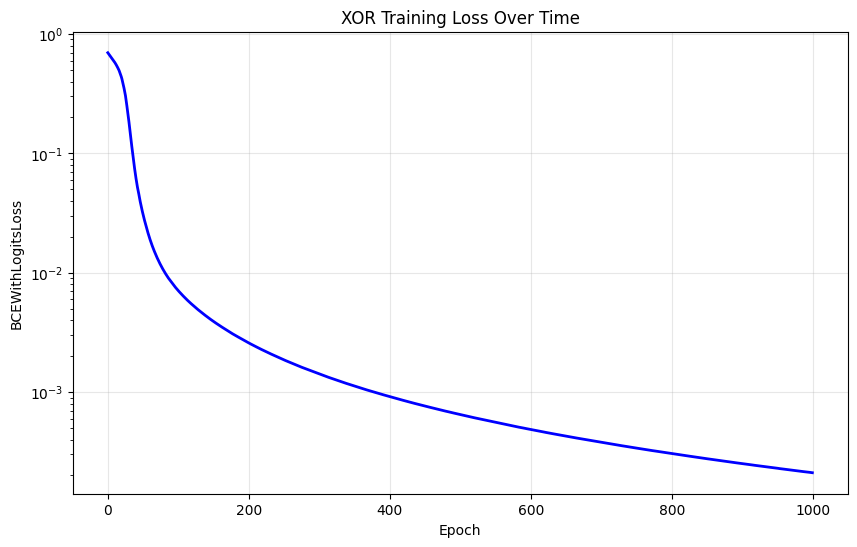

Loss decreased from 0.6973 to 0.0002


In [21]:
# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(losses_history, 'b-', linewidth=2)
plt.title('XOR Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogitsLoss')
plt.grid(True, alpha=0.3)
plt.yscale('log') # Log scale to better see the convergence
plt.show()
print(f"Loss decreased from {losses_history[0]:.4f} to {losses_history[-1]:.4f}")

In [22]:
# Step 5: Evaluate the Model
print("Step 5: Model Evaluation")
print("-" * 25)
xor_model.eval() # Set to evaluation mode
with torch.no_grad():
  test_predictions_logits = xor_model(X_xor)
  test_predictions_probs = torch.sigmoid(test_predictions_logits)
  predicted_classes = (test_predictions_probs >= 0.5).float()

  accuracy = (predicted_classes == y_xor).float().mean()

  print(f"Final Accuracy: {accuracy.item()*100:.2f}%")
  print("\nDetailed Results:")
  print("Input | True | Pred Prob | Pred Class | Correct")
  print("-------" + "|" + "------" + "|" + "-----------" + "|" + "------------" + "|" + "--------")

  for i in range(len(X_xor)):
    input_vals = X_xor[i].cpu().numpy()
    true_val = y_xor[i].item()
    pred_prob = test_predictions_probs[i].item()
    pred_class = predicted_classes[i].item()
    correct = "✓" if pred_class == true_val else "✗"

    print(f"{input_vals} | {true_val:.0f} | {pred_prob:.4f} | {pred_class:.0f} | {correct}")
xor_model.train() # Set back to training mode

Step 5: Model Evaluation
-------------------------
Final Accuracy: 100.00%

Detailed Results:
Input | True | Pred Prob | Pred Class | Correct
-------|------|-----------|------------|--------
[0. 0.] | 0 | 0.0007 | 0 | ✓
[0. 1.] | 1 | 1.0000 | 1 | ✓
[1. 0.] | 1 | 1.0000 | 1 | ✓
[1. 1.] | 0 | 0.0000 | 0 | ✓


XORNet(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=1, bias=True)
)

## 10.sections

In [23]:
import torch
import torch.nn as nn # Though not heavily used, good to have for context with nn.Module
import numpy as np
import matplotlib.pyplot as plt # For graph visualization concept
import os

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create output directory for plots if it doesn't exist
output_dir = "03_automatic_differentiation_outputs"
os.makedirs(output_dir, exist_ok=True)

# -----------------------------------------------------------------------------
# Section 1: Introduction to Automatic Differentiation
# (Conceptual, covered in detail in README.md)
# -----------------------------------------------------------------------------

def intro_to_automatic_differentiation_concepts():
    """Prints a summary of Automatic Differentiation concepts."""
    print("\nSection 1: Introduction to Automatic Differentiation")
    print("-" * 70)
    print("Key Concepts (Detailed in README.md):")
    print("  - Differentiation: Manual, Symbolic, Automatic (AD). PyTorch uses Reverse Mode AD.")
    print("  - Why AD for Deep Learning: Efficient gradient computation for complex models.")

# -----------------------------------------------------------------------------
# Section 2: PyTorch Autograd: The Basics
# -----------------------------------------------------------------------------

def demonstrate_autograd_basics():
    """Demonstrates requires_grad, grad_fn, backward(), and .grad attribute."""
    print("\nSection 2: PyTorch Autograd: The Basics")
    print("-" * 70)

    # --- Tensors and `requires_grad` ---
    print("\n--- Tensors and `requires_grad` ---")
    # Create a tensor that requires gradient tracking
    x = torch.tensor(2.0, requires_grad=True, device=device)
    print(f"x: {x}, requires_grad: {x.requires_grad}")

    # Create a tensor that does not require gradients (default)
    w = torch.tensor(5.0, device=device)
    print(f"w: {w}, requires_grad: {w.requires_grad}")

    # Operations involving a tensor with requires_grad=True will result in a tensor that also requires_grad
    y = x * w # y will require gradients because x does
    print(f"y = x * w: {y}, requires_grad: {y.requires_grad}")

    # --- The `grad_fn` (Gradient Function) ---
    print("\n--- The `grad_fn` (Gradient Function) ---")
    print(f"y.grad_fn: {y.grad_fn}") # Shows the function that created y (e.g., <MulBackward0>)
    print(f"x.grad_fn: {x.grad_fn}") # x is a leaf tensor created by user, so grad_fn is None
    print(f"w.grad_fn: {w.grad_fn}") # w does not require grad, so grad_fn is None

    # --- Computing Gradients: `backward()` ---
    print("\n--- Computing Gradients: `backward()` ---")
    # Let's define a scalar output for simplicity
    z = y**2 + x # z = (2*5)^2 + 2 = 10^2 + 2 = 102
    print(f"z = y**2 + x: {z}, grad_fn: {z.grad_fn}")

    # Compute gradients of z with respect to all tensors with requires_grad=True
    # that z depends on (in this case, only x, as w.requires_grad=False)
    z.backward() # dz/dx is computed

    # --- Accessing Gradients: `.grad` attribute ---
    print("\n--- Accessing Gradients: `.grad` attribute ---")
    # dz/dx = d/dx ((x*w)^2 + x) = 2*(x*w)*w + 1 = 2*x*w^2 + 1
    # At x=2, w=5: dz/dx = 2*2*5^2 + 1 = 4*25 + 1 = 100 + 1 = 101
    print(f"Gradient dz/dx: {x.grad}")
    print(f"Gradient dz/dw (w.grad): {w.grad}") # w.grad is None because w.requires_grad was False

    # Another example
    a = torch.tensor(3.0, requires_grad=True, device=device)
    b = a * a # b = 9
    out = b.mean() # For a single element tensor, mean is itself. Scalar output.
    out.backward()
    print(f"a: {a}, Gradient dout/da: {a.grad}") # d(a^2)/da = 2a = 6

# -----------------------------------------------------------------------------
# Section 3: The Computational Graph
# -----------------------------------------------------------------------------

def demonstrate_computational_graph():
    """Illustrates the concept of the dynamic computational graph."""
    print("\nSection 3: The Computational Graph")
    print("-" * 70)
    print("PyTorch uses dynamic computational graphs (define-by-run).")

    a = torch.tensor(2.0, requires_grad=True, device=device)
    b = torch.tensor(4.0, requires_grad=True, device=device)
    print(f"Leaf tensor a: is_leaf={a.is_leaf}, requires_grad={a.requires_grad}, grad_fn={a.grad_fn}")
    print(f"Leaf tensor b: is_leaf={b.is_leaf}, requires_grad={b.requires_grad}, grad_fn={b.grad_fn}")

    c = a + b # c is an intermediate tensor (non-leaf)
    print(f"Intermediate tensor c = a + b: is_leaf={c.is_leaf}, requires_grad={c.requires_grad}, grad_fn={c.grad_fn}")

    d = c * 3 # d is another intermediate tensor
    print(f"Intermediate tensor d = c * 3: is_leaf={d.is_leaf}, requires_grad={d.requires_grad}, grad_fn={d.grad_fn}")

    # The graph is: a --(+)--> c --(*)--> d
    #               b --(+)-->
    #               3 --(*)-->

    # Perform backward pass
    d.backward() # Computes dd/da and dd/db
                 # dd/dc = 3
                 # dc/da = 1, dc/db = 1
                 # dd/da = (dd/dc) * (dc/da) = 3 * 1 = 3
                 # dd/db = (dd/dc) * (dc/db) = 3 * 1 = 3

    print(f"Gradient dd/da: {a.grad}")
    print(f"Gradient dd/db: {b.grad}")
    print(f"Gradient dd/dc (c.grad): {c.grad}") # None by default for non-leaf unless retain_grad() is used

    # Simple graph visualization concept (manual plotting)
    fig, ax = plt.subplots(figsize=(6,4))
    ax.text(0.1, 0.8, "a (leaf)", bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', ec='blue', lw=1))
    ax.text(0.1, 0.2, "b (leaf)", bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', ec='blue', lw=1))
    ax.text(0.5, 0.5, "c = a + b\n(grad_fn=AddBackward)", ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', fc='lightgreen', ec='green', lw=1))
    ax.text(0.9, 0.5, "d = c * 3\n(grad_fn=MulBackward)", ha='center', va='center', bbox=dict(boxstyle='round,pad=0.3', fc='lightcoral', ec='red', lw=1))
    ax.annotate("", xy=(0.4, 0.5), xytext=(0.2, 0.8), arrowprops=dict(arrowstyle="->"))
    ax.annotate("", xy=(0.4, 0.5), xytext=(0.2, 0.2), arrowprops=dict(arrowstyle="->"))
    ax.annotate("", xy=(0.75, 0.5), xytext=(0.65, 0.5), arrowprops=dict(arrowstyle="->"))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off'); plt.title("Conceptual Computational Graph")
    plot_path = os.path.join(output_dir, 'conceptual_graph.png')
    plt.savefig(plot_path); plt.close()
    print(f"Conceptual graph plot saved to '{plot_path}'")

# -----------------------------------------------------------------------------
# Section 4: Gradient Accumulation
# -----------------------------------------------------------------------------

def demonstrate_gradient_accumulation():
    """Shows how gradients accumulate and how to zero them."""
    print("\nSection 4: Gradient Accumulation")
    print("-" * 70)

    x = torch.tensor(3.0, requires_grad=True, device=device)

    # First computation
    y1 = x * 2 # dy1/dx = 2
    y1.backward() # Gradients are computed and stored in x.grad
    print(f"After first backward (y1=2x), x.grad: {x.grad}")

    # Second computation on the same x
    # If we don't zero x.grad, new gradients will be added to the existing ones.
    y2 = x * 3 # dy2/dx = 3
    y2.backward()
    print(f"After second backward (y2=3x) WITHOUT zeroing, x.grad: {x.grad}") # Expected: 2 + 3 = 5

    # --- Zeroing Gradients ---
    print("\n--- Zeroing Gradients ---")
    # Method 1: Manually zeroing the .grad attribute
    if x.grad is not None:
        x.grad.zero_()
    print(f"After x.grad.zero_(), x.grad: {x.grad}")

    # Recompute for y1 with fresh gradients
    y1_fresh = x * 2
    y1_fresh.backward()
    print(f"After y1_fresh.backward() with zeroed grad, x.grad: {x.grad}")

    # In a training loop, `optimizer.zero_grad()` is typically used before `loss.backward()`
    # model_params = [x] # Simulate model parameters
    # optimizer = torch.optim.SGD([x], lr=0.1) # Dummy optimizer
    # optimizer.zero_grad() # This would achieve the same for all params in optimizer
    # print(f"After optimizer.zero_grad() (conceptual), x.grad: {x.grad}")
    print("Use case: Simulating larger batch sizes by accumulating gradients over mini-batches.")

# -----------------------------------------------------------------------------
# Section 5: Excluding Tensors from Autograd (`torch.no_grad()`, `detach()`)
# -----------------------------------------------------------------------------

def demonstrate_excluding_from_autograd():
    """Illustrates `torch.no_grad()` and `tensor.detach()`."""
    print("\nSection 5: Excluding Tensors from Autograd")
    print("-" * 70)

    # --- `torch.no_grad()` ---
    print("\n--- `torch.no_grad()` ---")
    a = torch.tensor(5.0, requires_grad=True, device=device)
    print(f"a: {a}, requires_grad: {a.requires_grad}")

    with torch.no_grad():
        b = a * 2 # Operation within torch.no_grad()
        print(f"Inside torch.no_grad(): b = a * 2: {b}, requires_grad: {b.requires_grad}") # b.requires_grad will be False
        print(f"                         b.grad_fn: {b.grad_fn}") # b.grad_fn will be None

    # Operations outside the no_grad block will resume tracking if inputs require_grad
    c = a * 3
    print(f"Outside torch.no_grad(): c = a * 3: {c}, requires_grad: {c.requires_grad}, grad_fn: {c.grad_fn}")
    print("`torch.no_grad()` is useful for inference or when modifying parameters without tracking.")

    # --- `.detach()` ---
    print("\n--- `.detach()` ---")
    p = torch.tensor(4.0, requires_grad=True, device=device)
    q = p * p # q requires grad and has a grad_fn
    print(f"q = p*p: {q}, requires_grad: {q.requires_grad}, grad_fn: {q.grad_fn}")

    r = q.detach() # r shares data with q but is detached from the graph
    print(f"r = q.detach(): {r}, requires_grad: {r.requires_grad}, grad_fn: {r.grad_fn}")

    # Modifying r does not affect q's gradient computation if q is used later
    # However, if q itself is modified in-place, it can cause issues.
    # r[0] = 100.0 # If r was a multi-element tensor, this would modify q's data too.
    # print(f"q after modifying detached r: {q}")

    # If we try to backpropagate from r, it won't affect p
    try:
        # r.sum().backward() # This would error if r had no requires_grad and was leaf, or do nothing for p if not leaf.
        # If we make r require grad AFTER detaching, it starts a new history
        r_requiring_grad = q.detach().requires_grad_(True)
        s = r_requiring_grad * 2
        s.sum().backward() # This computes ds/dr_requiring_grad
        print(f"r_requiring_grad.grad: {r_requiring_grad.grad}") # Will have gradient
        print(f"p.grad after s.backward(): {p.grad}") # p.grad will be None or its old value, not affected by s
    except Exception as e:
        print(f"Error demonstrating backward on detached tensor: {e}")
    print("`.detach()` creates a new tensor sharing data but not history, useful for partial graph operations.")

# -----------------------------------------------------------------------------
# Section 6: Gradients of Non-Scalar Outputs (Vector-Jacobian Product)
# -----------------------------------------------------------------------------

def demonstrate_vector_jacobian_product():
    """Explains and shows `backward()` with non-scalar outputs."""
    print("\nSection 6: Gradients of Non-Scalar Outputs (Vector-Jacobian Product)")
    print("-" * 70)
    print("If `backward()` is called on a non-scalar tensor, a `gradient` argument is needed.")

    x_vjp = torch.randn(3, requires_grad=True, device=device) # Input vector
    y_vjp = x_vjp * 2 + 1 # Output vector y = [2x1+1, 2x2+1, 2x3+1]
    # Jacobian J = dy/dx would be a diagonal matrix with 2s on the diagonal.
    print(f"x_vjp: {x_vjp.data}")
    print(f"y_vjp: {y_vjp.data}")

    # If we call y_vjp.backward() directly, it errors:
    # "grad can be implicitly created only for scalar outputs"
    try:
        y_vjp.backward()
    except RuntimeError as e:
        print(f"Error calling y_vjp.backward() without gradient arg: {e}")

    # We need to provide a `gradient` tensor (vector v in v^T * J)
    # This is often the gradient of the final scalar loss w.r.t y_vjp
    v = torch.tensor([0.1, 1.0, 0.01], device=device) # Example vector
    y_vjp.backward(gradient=v)
    # x_vjp.grad will be v^T * J. Since J is diag(2,2,2), x_vjp.grad = v * 2
    print(f"Provided vector v: {v}")
    print(f"x_vjp.grad (should be v * 2): {x_vjp.grad}")

    # Use case: If you have a model producing multiple outputs (y_vjp) and your loss
    # is L = sum(y_vjp * some_weights), then dl/dy_vjp = some_weights, which you pass as `gradient`.

# -----------------------------------------------------------------------------
# Section 7: Higher-Order Derivatives
# -----------------------------------------------------------------------------

def demonstrate_higher_order_derivatives():
    """Shows how to compute gradients of gradients."""
    print("\nSection 7: Higher-Order Derivatives")
    print("-" * 70)
    print("Autograd can compute higher-order derivatives (gradients of gradients).")

    x_ho = torch.tensor(2.0, requires_grad=True, device=device)
    y_ho = x_ho**4 # y = x^4
                   # dy/dx = 4x^3
                   # d^2y/dx^2 = 12x^2
                   # d^3y/dx^3 = 24x

    # --- First derivative ---
    # Method 1: Using y_ho.backward(create_graph=True) and then x_ho.grad
    # (less direct for just getting the grad value, better for graph construction)
    # y_ho.backward(create_graph=True)
    # dy_dx = x_ho.grad.clone() # Must clone if we zero grad later
    # print(f"dy/dx at x={x_ho.item()}: {dy_dx} (Using backward)")
    # x_ho.grad.zero_() # Clean up for next method

    # Method 2: Using torch.autograd.grad()
    dy_dx = torch.autograd.grad(outputs=y_ho, inputs=x_ho, create_graph=True)[0]
    # `create_graph=True` is crucial for enabling further differentiation on dy_dx
    print(f"y = x^4 at x={x_ho.item()} is {y_ho.item()}")
    print(f"dy/dx (4x^3) at x={x_ho.item()}: {dy_dx.item()}")

    # --- Second derivative ---
    d2y_dx2 = torch.autograd.grad(outputs=dy_dx, inputs=x_ho, create_graph=True)[0]
    print(f"d^2y/dx^2 (12x^2) at x={x_ho.item()}: {d2y_dx2.item()}")

    # --- Third derivative ---
    d3y_dx3 = torch.autograd.grad(outputs=d2y_dx2, inputs=x_ho, create_graph=False)[0] # No more differentiation needed
    print(f"d^3y/dx^3 (24x) at x={x_ho.item()}: {d3y_dx3.item()}")
    print("Requires `create_graph=True` in `backward()` or `torch.autograd.grad()`.")

# -----------------------------------------------------------------------------
# Section 8: In-place Operations and Autograd
# -----------------------------------------------------------------------------

def demonstrate_inplace_operations():
    """Discusses potential issues with in-place operations."""
    print("\nSection 8: In-place Operations and Autograd")
    print("-" * 70)
    print("In-place operations (e.g., `x.add_(1)`) modify content directly and can cause issues with autograd if not handled carefully.")

    # Example that WILL cause a RuntimeError if not handled, demonstrating the issue
    print("\n--- Demonstrating the RuntimeError with in-place modification ---")
    a = torch.tensor(2.0, requires_grad=True, device=device)
    b = a * 2 # b depends on the original value of a
    print(f"Initial a: {a.item()}, b = a * 2: {b.item()}")

    try:
        print("Attempting in-place modification on leaf tensor 'a': a.add_(1)")
        a.add_(1) # This is the line that causes the RuntimeError
        print(f"Modified a (in-place): {a.item()} (This line may not be reached if error occurs)")
        # If this point is reached, trying to backward b might still fail or yield incorrect results
        # as b's grad_fn would expect the original 'a'.
        b.backward() # This would attempt to compute gradient using original 'a'
        print(f"Gradient db/da: {a.grad} (This outcome is unexpected if error occurred before)")
    except RuntimeError as e:
        print(f"Caught expected RuntimeError: {e}")
        print("\nExplanation: PyTorch Autograd raises this error because modifying 'a' in-place breaks the computational graph needed to compute gradients for 'b'. The backward pass for 'b' requires the original value of 'a'.")

    # Example of how to avoid the error for similar logic (using out-of-place assignment)
    print("\n--- Avoiding the issue with an out-of-place operation ---")
    a_safe = torch.tensor(2.0, requires_grad=True, device=device)
    b_safe = a_safe * 2 # b_safe depends on the original a_safe
    print(f"Initial a_safe: {a_safe.item()}, b_safe = a_safe * 2: {b_safe.item()}")

    # Perform an out-of-place modification on a_safe
    # This creates a NEW tensor for a_safe, so the original a_safe (used by b_safe's grad_fn) is untouched.
    a_safe_new = a_safe + 1.0
    print(f"New tensor a_safe_new (out-of-place): {a_safe_new.item()}")

    # Now, if we backward b_safe, it will work correctly because its dependency (the *original* a_safe)
    # was not modified. Note that a_safe_new is a separate tensor.
    b_safe.backward() # Correctly computes gradient db_safe/da_safe using the original a_safe
    print(f"Gradient db_safe/da_safe: {a_safe.grad.item()} (Correctly 2.0)")
    print(f"Note: The new tensor 'a_safe_new' does not have a .grad attribute from this operation.")

    print("\nIt is generally safer to use out-of-place operations (e.g., `a = a + 1`) when unsure.")

# -----------------------------------------------------------------------------
# Section 9: Custom Autograd Functions (`torch.autograd.Function`)
# -----------------------------------------------------------------------------

class MyCubeFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, input_tensor):
        """Computes input_tensor^3."""
        # ctx is a context object to save information for backward pass
        ctx.save_for_backward(input_tensor) # Save input_tensor for gradient calculation
        return input_tensor**3

    @staticmethod
    def backward(ctx, grad_output):
        """Computes gradient of input_tensor^3, which is 3 * input_tensor^2."""
        # grad_output is the gradient of the loss w.r.t. the output of this function
        input_tensor, = ctx.saved_tensors # Retrieve saved tensor
        # Gradient of L w.r.t. input = (gradient of L w.r.t. output) * (gradient of output w.r.t. input)
        # Here, gradient of output w.r.t. input is 3 * input_tensor^2
        grad_input = grad_output * 3 * input_tensor**2
        return grad_input # Must return as many gradients as there were inputs to forward

def demonstrate_custom_autograd_function():
    """Shows how to implement and use a custom autograd Function."""
    print("\nSection 9: Custom Autograd Functions (`torch.autograd.Function`)")
    print("-" * 70)
    print("Allows defining custom operations with user-defined forward and backward passes.")

    # Get the function to apply
    custom_cube = MyCubeFunction.apply

    x_custom = torch.tensor(2.0, requires_grad=True, device=device)
    y_custom = custom_cube(x_custom) # y = x^3 = 2^3 = 8
    print(f"x_custom: {x_custom.item()}, y_custom (x^3): {y_custom.item()}")

    # Perform backward pass
    y_custom.backward() # Computes dy/dx = 3x^2
    print(f"Gradient dy_custom/dx_custom (should be 3*2^2 = 12): {x_custom.grad}")

    # Compare with PyTorch's automatic differentiation
    x_auto = torch.tensor(2.0, requires_grad=True, device=device)
    y_auto = x_auto**3
    y_auto.backward()
    print(f"Gradient dy_auto/dx_auto (using PyTorch AD): {x_auto.grad}")
    print("Custom function gradient matches PyTorch's AD.")

# -----------------------------------------------------------------------------
# Section 10: Practical Considerations and Tips
# -----------------------------------------------------------------------------

def practical_considerations_autograd():
    print("\nSection 10: Practical Considerations and Tips")
    print("-" * 70)

    x = torch.randn(2, 2, requires_grad=True, device=device)
    y = x + 2 # y requires_grad, is_leaf=False
    z = y * y * 3
    out = z.mean() # Scalar output

    # Checking `requires_grad`
    print(f"x.requires_grad: {x.requires_grad}") # True
    print(f"y.requires_grad: {y.requires_grad}") # True
    intermediate_tensor = torch.tensor([1., 2.], device=device) # Default requires_grad=False
    print(f"intermediate_tensor.requires_grad: {intermediate_tensor.requires_grad}") # False

    # Checking `is_leaf`
    print(f"x.is_leaf: {x.is_leaf}") # True (created by user with requires_grad=True)
    print(f"y.is_leaf: {y.is_leaf}") # False (result of an operation)
    # Model parameters are leaf tensors: model.weight.is_leaf would be True

    # `retain_graph=True`
    # Normally, the graph is freed after backward(). Use retain_graph=True if you need to backprop again.
    out.backward(retain_graph=True) # First backward pass
    print(f"x.grad after first backward: {x.grad.clone().flatten().cpu().numpy()}") # Clone to print before next backward might change it

    # If you call backward again on `out` or another part of the same graph without retain_graph=True
    # in the first call, it would error. With retain_graph=True, it works.
    # Gradients will accumulate if not zeroed.
    x.grad.zero_() # Zero gradients before next backward pass
    out.backward() # Second backward pass (possible due to retain_graph=True)
    print(f"x.grad after second backward (with zeroing): {x.grad.flatten().cpu().numpy()}")
    print("`retain_graph=True` is needed for multiple backward passes from the same graph part.")
    print("Memory usage: Autograd stores intermediate values. `del` tensors or use `torch.no_grad()` for inference to save memory.")

# -----------------------------------------------------------------------------
# Main function to run all sections
# -----------------------------------------------------------------------------

def main():
    """Main function to run all Autograd tutorial sections."""
    print("=" * 80)
    print("Automatic Differentiation with PyTorch Autograd Tutorial")
    print("=" * 80)

    intro_to_automatic_differentiation_concepts()
    demonstrate_autograd_basics()
    demonstrate_computational_graph()
    demonstrate_gradient_accumulation()
    demonstrate_excluding_from_autograd()
    demonstrate_vector_jacobian_product()
    demonstrate_higher_order_derivatives()
    demonstrate_inplace_operations()
    demonstrate_custom_autograd_function()
    practical_considerations_autograd()

    print("\nTutorial complete! Plots are in '03_automatic_differentiation_outputs' directory.")

Using device: cpu


In [24]:
main()

Automatic Differentiation with PyTorch Autograd Tutorial

Section 1: Introduction to Automatic Differentiation
----------------------------------------------------------------------
Key Concepts (Detailed in README.md):
  - Differentiation: Manual, Symbolic, Automatic (AD). PyTorch uses Reverse Mode AD.
  - Why AD for Deep Learning: Efficient gradient computation for complex models.

Section 2: PyTorch Autograd: The Basics
----------------------------------------------------------------------

--- Tensors and `requires_grad` ---
x: 2.0, requires_grad: True
w: 5.0, requires_grad: False
y = x * w: 10.0, requires_grad: True

--- The `grad_fn` (Gradient Function) ---
y.grad_fn: <MulBackward0 object at 0x00000273859A2B00>
x.grad_fn: None
w.grad_fn: None

--- Computing Gradients: `backward()` ---
z = y**2 + x: 102.0, grad_fn: <AddBackward0 object at 0x00000273859A31F0>

--- Accessing Gradients: `.grad` attribute ---
Gradient dz/dx: 101.0
Gradient dz/dw (w.grad): None
a: 3.0, Gradient dout/da

C:\Users\ACER\AppData\Local\Temp\ipykernel_14620\1870732414.py:119: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:499.)
  print(f"Gradient dd/dc (c.grad): {c.grad}") # None by default for non-leaf unless retain_grad() is used


# Chiều Lý Thuyết

## 1.Huấn luyện mô hình mạng nơ rộng: hướng dẫn toàn diện

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset
from torch.optim.lr_scheduler import StepLR, MultiStepLR, ExponentialLR, CosineAnnealingLR, ReduceLROnPlateau
from torch.nn.utils import clip_grad_norm_, clip_grad_value_
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import math


In [26]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Create output directory for plots, models, and logs
output_dir = "04_training_neural_networks_outputs"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(os.path.join(output_dir, "runs"), exist_ok=True)
os.makedirs(os.path.join(output_dir, "saved_models"), exist_ok=True)


Using device: cpu


## 2.Chuan bị Dataset và DataLoader

In [27]:
class MyCustomDataset(Dataset):
  """Example of a custom Dataset."""
  def __init__(self, num_samples=1000, input_features=10, num_classes=2, transform=None):
    # Generate some random data for demonstration
    self.data = torch.randn(num_samples, input_features)
    self.targets = torch.randint(0, num_classes, (num_samples,))
    self.transform = transform
    print(f"CustomDataset: Created {num_samples} samples.")
  def __len__(self):
      return len(self.data)
  def __getitem__(self, idx):
    sample = self.data[idx]
    target = self.targets[idx]
    if self.transform:
      sample = self.transform(sample)
    return sample, torch.tensor(target, dtype=torch.long)
# Using the custom dataset
print ("--- Custom Dataset Example ---")
custom_train_dataset = MyCustomDataset(num_samples=100, input_features=5,num_classes=3)
sample_data, sample_target = custom_train_dataset[0]
print(f"First sample data shape: {sample_data.shape}, target: {sample_target}")
# Using DataLoader with the custom dataset
custom_train_loader = DataLoader(custom_train_dataset, batch_size=32,shuffle=True)
print(f"Number of batches in custom_train_loader: {len(custom_train_loader)}")
for i, (batch_data, batch_targets) in enumerate(custom_train_loader):
 print(f"Batch {i+1} data shape: {batch_data.shape}, targets shape:{batch_targets.shape}")
 if i == 0: # Print only first batch details
    break




--- Custom Dataset Example ---
CustomDataset: Created 100 samples.
First sample data shape: torch.Size([5]), target: 1
Number of batches in custom_train_loader: 4
Batch 1 data shape: torch.Size([32, 5]), targets shape:torch.Size([32])


C:\Users\ACER\AppData\Local\Temp\ipykernel_14620\1705069661.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return sample, torch.tensor(target, dtype=torch.long)


In [28]:
 # Using torchvision for a standard dataset (MNIST)
print("\n--- torchvision MNIST Dataset and DataLoader Example ---")
mnist_transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize((0.1307,), (0.3081,)) # MNIST mean and std
])
mnist_train_dataset = torchvision.datasets.MNIST(
root='./data', train=True, download=True, transform=mnist_transform
)
mnist_train_loader = DataLoader(mnist_train_dataset, batch_size=64,shuffle=True)
print(f"Number of samples in MNIST training set: {len(mnist_train_dataset)}")
print(f"Number of batches in MNIST train_loader: {len(mnist_train_loader)}")
mnist_batch_data, mnist_batch_targets = next(iter(mnist_train_loader))
print(f"MNIST first batch data shape: {mnist_batch_data.shape}, targets shape:{mnist_batch_targets.shape}")
print("`Dataset` manages data samples, `DataLoader` provides batches for training.")



--- torchvision MNIST Dataset and DataLoader Example ---


100.0%
100.0%
100.0%
100.0%

Number of samples in MNIST training set: 60000
Number of batches in MNIST train_loader: 938
MNIST first batch data shape: torch.Size([64, 1, 28, 28]), targets shape:torch.Size([64])
`Dataset` manages data samples, `DataLoader` provides batches for training.


## 1.3 Định nghĩa mạng nơ ron

In [29]:
class SimpleNN(nn.Module):
  def __init__(self, input_size=28*28, hidden_size=128, num_classes=10,use_dropout=False, use_bn=False):
    super(SimpleNN, self).__init__()
    self.use_dropout = use_dropout
    self.use_bn = use_bn
    self.fc1 = nn.Linear(input_size, hidden_size)
    if self.use_bn:
      self.bn1 = nn.BatchNorm1d(hidden_size)
    self.relu = nn.ReLU()
    if self.use_dropout:
      self.dropout = nn.Dropout(0.5)
    self.fc2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    x = x.view(x.size(0), -1) # Flatten the input
    x = self.fc1(x)
    if self.use_bn:
      x = self.bn1(x)
    x = self.relu(x)
    if self.use_dropout:
      x = self.dropout(x)
    x = self.fc2(x)
    return x

In [30]:
# Create a model instance
model = SimpleNN().to(device)
print("Neural Network Architecture:")
print(model)


Neural Network Architecture:
SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 1.4 Vòng lặp huấn luyện

In [31]:
# Dummy data for demonstration
dummy_inputs = torch.randn(64, 28*28).to(device) # Batch of 64 flattened images
dummy_targets = torch.randint(0, 10, (64,)).to(device) # 64 labels for 10 classes
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print("Running one iteration of the training loop...")
# 1. Set model to training mode
model.train()
# 2. Zero gradients (typically at start of batch loop)
optimizer.zero_grad()
# 3. Forward pass: Getting predictions
outputs = model(dummy_inputs)
print(f" Output shape: {outputs.shape}")
# 4. Calculate the loss
loss = criterion(outputs, dummy_targets)
print(f" Calculated loss: {loss.item():.4f}")
# 5. Backward pass: Computing gradients
loss.backward()
print(f" Gradients computed (e.g., model.fc1.weight.grad is not None: {model.fc1.weight.grad is not None})")
# 6. Optimizer step: Updating weights
optimizer.step()
print(f" Optimizer step taken (weights updated).")
print("This forms one iteration. A full epoch repeats this for all batches.")

Running one iteration of the training loop...
 Output shape: torch.Size([64, 10])
 Calculated loss: 2.2871
 Gradients computed (e.g., model.fc1.weight.grad is not None: True)
 Optimizer step taken (weights updated).
This forms one iteration. A full epoch repeats this for all batches.


##1.5

In [32]:
def get_mnist_loaders(batch_size=64, validation_split=0.1):
    """Helper function to get MNIST data loaders"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    num_train = len(full_train_dataset)
    val_size = int(validation_split * num_train)
    train_size = num_train - val_size
    train_subset, val_subset = random_split(full_train_dataset, [train_size, val_size])
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

# Get data loaders
train_loader, val_loader, test_loader = get_mnist_loaders()
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 844, Val batches: 94, Test batches: 157


In [33]:
# Validation loop demonstration
model = SimpleNN().to(device)
criterion = nn.CrossEntropyLoss()
print("Running one validation epoch...")
# 1. Set model to evaluation mode
model.eval()
val_loss = 0.0
correct_predictions = 0
total_samples = 0

Running one validation epoch...


In [34]:
# 2. Disable gradient computation
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        val_loss += loss.item() * inputs.size(0)
        _, predicted_classes = outputs.max(1)
        total_samples += targets.size(0)
        correct_predictions += predicted_classes.eq(targets).sum().item()
        # Print only first batch details
        if total_samples == inputs.size(0):
            print(f" Validation batch: Loss={loss.item():.4f}")
        # Break after a few batches for demo
        if total_samples >= 256:
            break
epoch_loss = val_loss / total_samples
epoch_accuracy = correct_predictions / total_samples
print(f"Validation Results: Average Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy*100:.2f}%")
print("`model.eval()` and `torch.no_grad()` are crucial for correct validation.")

 Validation batch: Loss=2.3149
Validation Results: Average Loss: 2.3294, Accuracy: 8.98%
`model.eval()` and `torch.no_grad()` are crucial for correct validation.


## 1.6

In [35]:
# Create and train a model briefly for saving
model_to_save = SimpleNN().to(device)
optimizer = optim.Adam(model_to_save.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
# Simulate some training
dummy_input = torch.randn(10, 28*28).to(device)
dummy_target = torch.randint(0, 10, (10,)).to(device)
for _ in range(2): # Few dummy steps
  optimizer.zero_grad()
  loss = criterion(model_to_save(dummy_input), dummy_target)
  loss.backward()
  optimizer.step()
model_path = os.path.join(output_dir, "saved_models", "simple_nn_statedict.pth")
checkpoint_path = os.path.join(output_dir, "saved_models", "checkpoint.pth")

In [36]:
# --- Saving and Loading State Dictionary (Recommended) ---
print("--- Saving and Loading Model State Dictionary ---")
torch.save(model_to_save.state_dict(), model_path)
print(f"Model state_dict saved to: {model_path}")
# Load the state_dict
model_loaded_state_dict = SimpleNN().to(device) # Create a new instance
model_loaded_state_dict.load_state_dict(torch.load(model_path))
model_loaded_state_dict.eval() # Set to evaluation mode
print("Model loaded from state_dict successfully.")

--- Saving and Loading Model State Dictionary ---
Model state_dict saved to: 04_training_neural_networks_outputs\saved_models\simple_nn_statedict.pth
Model loaded from state_dict successfully.


In [37]:
# --- Saving and Loading Checkpoints (for resuming training) ---
print("\n--- Saving and Loading Checkpoints ---")
epoch = 5
current_loss = 0.123
checkpoint = {
'epoch': epoch + 1, # Save next epoch to start from
'model_state_dict': model_to_save.state_dict(),
'optimizer_state_dict': optimizer.state_dict(),
'loss': current_loss,
}
torch.save(checkpoint, checkpoint_path)
print(f"Checkpoint saved to: {checkpoint_path}")


--- Saving and Loading Checkpoints ---
Checkpoint saved to: 04_training_neural_networks_outputs\saved_models\checkpoint.pth


In [38]:
# Load from checkpoint
model_for_resume = SimpleNN().to(device)
optimizer_for_resume = optim.Adam(model_for_resume.parameters(), lr=0.001)
loaded_checkpoint = torch.load(checkpoint_path)
model_for_resume.load_state_dict(loaded_checkpoint['model_state_dict'])
optimizer_for_resume.load_state_dict(loaded_checkpoint['optimizer_state_dict'])
start_epoch = loaded_checkpoint['epoch']
previous_loss = loaded_checkpoint['loss']
model_for_resume.train() # Set to train mode to resume training
print(f"Checkpoint loaded. Resuming from epoch {start_epoch}, previous loss:␣{previous_loss:.4f}")
print("Always save `state_dict` for portability and flexibility.")

Checkpoint loaded. Resuming from epoch 6, previous loss:␣0.1230
Always save `state_dict` for portability and flexibility.


## 1.7

C:\Users\ACER\AppData\Local\Temp\ipykernel_14620\1304793855.py:32: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  current_scheduler.step()


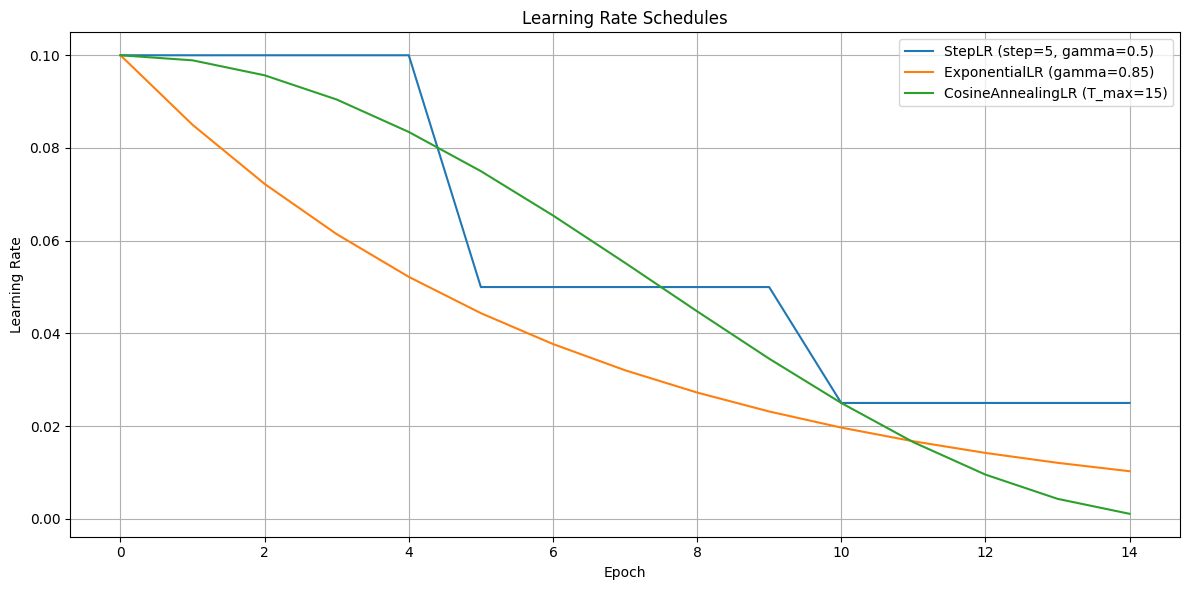

Different schedulers provide various learning rate decay patterns.


In [39]:
# Demonstrate different learning rate schedulers
model = SimpleNN(hidden_size=32).to(device) # Smaller model for quick demo
optimizer = optim.SGD(model.parameters(), lr=0.1)
num_epochs_lr_demo = 15
schedulers_to_test = {
  "StepLR (step=5, gamma=0.5)": StepLR(optimizer, step_size=5, gamma=0.5),
  "ExponentialLR (gamma=0.85)": ExponentialLR(optimizer, gamma=0.85),
  "CosineAnnealingLR (T_max=15)": CosineAnnealingLR(optimizer, T_max=num_epochs_lr_demo),
}

plt.figure(figsize=(12, 6))

# Note: Re-create the optimizer for each scheduler to ensure independent testing.
# The current setup will modify the same optimizer instance repeatedly if not handled.
# For demonstration, we will re-initialize optimizer inside the loop.

for name, scheduler_instance_template in schedulers_to_test.items():
    # Reset optimizer for each scheduler test
    optimizer = optim.SGD(model.parameters(), lr=0.1)

    # Re-create scheduler with new optimizer based on the type
    if "StepLR" in name:
        current_scheduler = StepLR(optimizer, step_size=5, gamma=0.5)
    elif "ExponentialLR" in name:
        current_scheduler = ExponentialLR(optimizer, gamma=0.85)
    elif "CosineAnnealingLR" in name:
        current_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs_lr_demo)

    lr_history = []
    for epoch in range(num_epochs_lr_demo):
        lr_history.append(optimizer.param_groups[0]['lr'])
        current_scheduler.step()

    plt.plot(lr_history, label=name)

plt.title("Learning Rate Schedules")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Different schedulers provide various learning rate decay patterns.")

## 1.8

In [40]:
# --- L2 Regularization (Weight Decay) ---
print("--- L2 Regularization (Weight Decay) ---")
model_wd = SimpleNN().to(device)
# Add weight_decay to the optimizer
optimizer_wd = optim.Adam(model_wd.parameters(), lr=0.001, weight_decay=1e-4)
print(f"Optimizer with weight_decay (L2 penalty): weight_decay={optimizer_wd.param_groups[0]['weight_decay']}")
# --- Dropout ---
print("\n--- Dropout ---")
model_dropout = SimpleNN(use_dropout=True).to(device)
print("Model with Dropout layer:")
print(model_dropout)

# Demonstrate dropout behavior
model_dropout.train()
dummy_input_reg = torch.randn(5, 28*28).to(device)
output_train = model_dropout(dummy_input_reg)
print(f"Output with dropout (train mode): {output_train[0,:5]}")
model_dropout.eval()
output_eval = model_dropout(dummy_input_reg)
print(f"Output with dropout (eval mode): {output_eval[0,:5]}")
print("During training, dropout randomly zeros elements. During evaluation,␣it's disabled.")

--- L2 Regularization (Weight Decay) ---
Optimizer with weight_decay (L2 penalty): weight_decay=0.0001

--- Dropout ---
Model with Dropout layer:
SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Output with dropout (train mode): tensor([ 0.1142,  0.3119, -0.0864, -0.4815,  0.0927], grad_fn=<SliceBackward0>)
Output with dropout (eval mode): tensor([ 0.3309,  0.1268,  0.0962, -0.3348,  0.4930], grad_fn=<SliceBackward0>)
During training, dropout randomly zeros elements. During evaluation,␣it's disabled.


## 1.9

In [41]:
model_gc = SimpleNN().to(device)
optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.01)
criterion_gc = nn.MSELoss()
dummy_input_gc = torch.randn(5, 28*28).to(device)
dummy_target_gc = torch.randn(5, 10).to(device)
optimizer_gc.zero_grad()
outputs_gc = model_gc(dummy_input_gc)
loss_gc = criterion_gc(outputs_gc, dummy_target_gc)
loss_gc.backward()

# Print norm of gradients before clipping
original_grad_norm = model_gc.fc1.weight.grad.norm().item()
print(f"Original grad norm for fc1.weight: {original_grad_norm:.4f}")

# Clip gradient norm
max_norm = 1.0
total_norm_clipped = clip_grad_norm_(model_gc.parameters(), max_norm=max_norm)
print(f"Total norm of gradients after clipping by norm to {max_norm}:{total_norm_clipped:.4f}")
clipped_grad_norm = model_gc.fc1.weight.grad.norm().item()
print(f"Clipped grad norm for fc1.weight: {clipped_grad_norm:.4f}")

# Demonstrate gradient value clipping
optimizer_gc.zero_grad()
outputs_gc = model_gc(dummy_input_gc)
loss_gc = criterion_gc(outputs_gc, dummy_target_gc)
loss_gc.backward()
clip_val = 0.1
clip_grad_value_(model_gc.parameters(), clip_value=clip_val)
print(f"\nAfter clipping values to +/- {clip_val}:")
print(f" Min grad value: {model_gc.fc1.weight.grad.min().item():.4f}")
print(f" Max grad value: {model_gc.fc1.weight.grad.max().item():.4f}")
print("Gradient clipping is applied after .backward() and before .step().")

Original grad norm for fc1.weight: 3.5663
Total norm of gradients after clipping by norm to 1.0:3.8096
Clipped grad norm for fc1.weight: 0.9361

After clipping values to +/- 0.1:
 Min grad value: -0.0842
 Max grad value: 0.0919
Gradient clipping is applied after .backward() and before .step().


## 1.10

In [42]:
model_with_bn = SimpleNN(use_bn=True).to(device)
print("Model with Batch Normalization layer:")
print(model_with_bn)
dummy_input_bn = torch.randn(5, 28*28).to(device)

# Behavior in train() mode
model_with_bn.train()
output_bn_train = model_with_bn(dummy_input_bn)
print(f"\nOutput with BatchNorm (train mode) shape: {output_bn_train.shape}")
print(f"Running mean of bn1 after one forward pass (train): {model_with_bn.bn1.running_mean[0].item():.4f}")

Model with Batch Normalization layer:
SimpleNN(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

Output with BatchNorm (train mode) shape: torch.Size([5, 10])
Running mean of bn1 after one forward pass (train): 0.0496


In [43]:
# Behavior in eval() mode
model_with_bn.eval()
output_bn_eval = model_with_bn(dummy_input_bn)
print(f"Output with BatchNorm (eval mode) shape: {output_bn_eval.shape}")
print("`model.train()` and `model.eval()` are crucial for BatchNorm to work correctly.")
print("In train mode, BN uses batch statistics and updates running mean/var.")
print("In eval mode, BN uses computed running mean/var and does not update them.")

Output with BatchNorm (eval mode) shape: torch.Size([5, 10])
`model.train()` and `model.eval()` are crucial for BatchNorm to work correctly.
In train mode, BN uses batch statistics and updates running mean/var.
In eval mode, BN uses computed running mean/var and does not update them.


## 1.11

In [44]:
# Configuration
LEARNING_RATE = 0.001
BATCH_SIZE = 128
NUM_EPOCHS = 2 # Low for demo, typically 10-100+
HIDDEN_SIZE = 256
WEIGHT_DECAY = 1e-5
CLIP_GRAD_NORM = 1.0

In [45]:
# Data Loading
train_loader, val_loader, test_loader = get_mnist_loaders(batch_size=BATCH_SIZE)
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 422, Val batches: 47


In [46]:
# Model Definition with regularization
model = SimpleNN(28*28, HIDDEN_SIZE, 10, use_dropout=True, use_bn=True).to(device)

In [47]:
# Initialize weights
for m in model.modules():
  if isinstance(m, nn.Linear):
    nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
    if m.bias is not None:
      nn.init.zeros_(m.bias)

In [48]:
# Loss, Optimizer, Scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
print("Model and training setup complete.")

Model and training setup complete.


In [49]:
# Training Loop
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
for epoch in range(NUM_EPOCHS):
  print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")


Epoch 1/2

Epoch 2/2


In [50]:
# Training Phase
model.train()
train_loss = 0.0
train_correct = 0
train_total = 0
for batch_idx, (inputs, targets) in enumerate(train_loader):
  inputs, targets = inputs.to(device), targets.to(device)
  optimizer.zero_grad()
  outputs = model(inputs)
  loss = criterion(outputs, targets)
  loss.backward()

In [51]:
# Gradient Clipping
if CLIP_GRAD_NORM > 0:
  clip_grad_norm_(model.parameters(), max_norm=CLIP_GRAD_NORM)
optimizer.step()
train_loss += loss.item() * inputs.size(0)
_, predicted = outputs.max(1)
train_total += targets.size(0)
train_correct += predicted.eq(targets).sum().item()
if (batch_idx + 1) % 100 == 0:
  batch_acc = predicted.eq(targets).sum().item() / targets.size(0)
  print(f' Batch {batch_idx+1}/{len(train_loader)} | Loss: {loss.item():.4f} | Acc: {batch_acc*100:.2f}%')
avg_train_loss = train_loss / train_total
avg_train_acc = train_correct / train_total

In [52]:
# Validation Phase
model.eval()
val_loss = 0.0
val_correct = 0
val_total = 0
with torch.no_grad():
    for inputs, targets in val_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        val_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        val_total += targets.size(0)
        val_correct += predicted.eq(targets).sum().item()
avg_val_loss = val_loss / val_total
avg_val_acc = val_correct / val_total

In [53]:
# Update scheduler
current_lr = optimizer.param_groups[0]['lr']
scheduler.step(avg_val_loss)

In [54]:
# Store history
history['train_loss'].append(avg_train_loss)
history['train_acc'].append(avg_train_acc)
history['val_loss'].append(avg_val_loss)
history['val_acc'].append(avg_val_acc)
history['lr'].append(current_lr)
print(f" Train Loss: {avg_train_loss:.4f}, Train Acc: {avg_train_acc*100:.2f}%")
print(f" Val Loss: {avg_val_loss:.4f}, Val Acc: {avg_val_acc*100:.2f}%")
print(f" Learning Rate: {current_lr:.6f}")
print("\nTraining completed!")

 Train Loss: 3.1765, Train Acc: 8.93%
 Val Loss: 2.5373, Val Acc: 14.28%
 Learning Rate: 0.001000

Training completed!


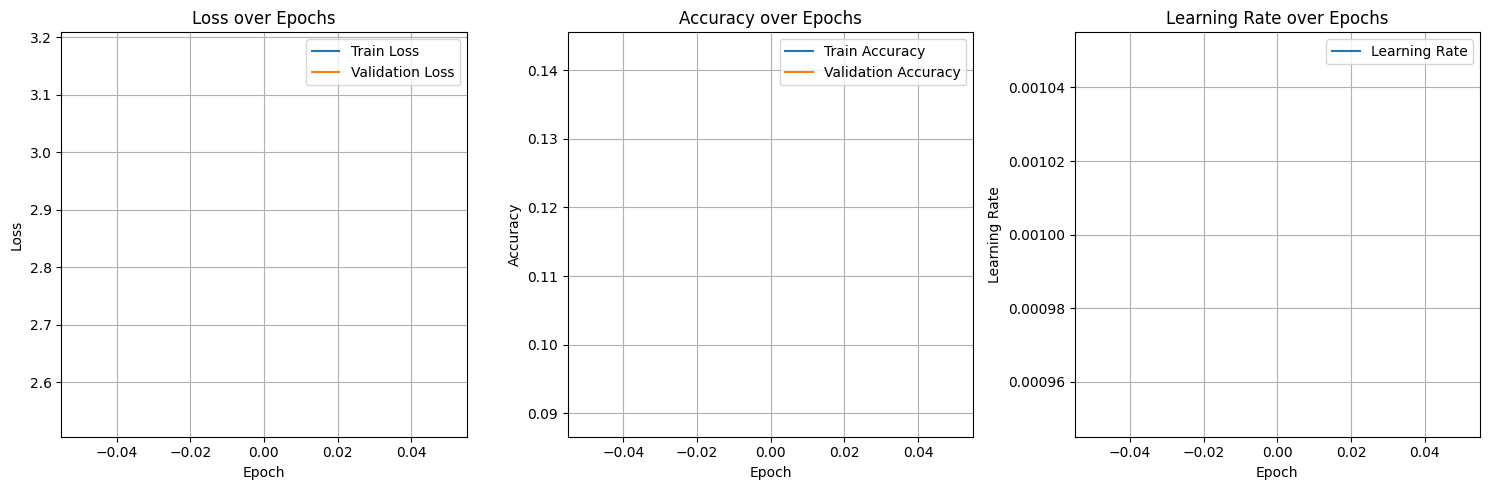

Training history visualization complete.


In [55]:
# Plot training history
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.subplot(1, 3, 3)
plt.plot(history['lr'], label='Learning Rate')
plt.title('Learning Rate over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
print("Training history visualization complete.")